# Cuaderno 3: Modelado Analitico y Predictivo
**Proyecto Final — Analisis de Subsidios de Vivienda en Colombia**

---
Este cuaderno implementa modelos de machine learning para predecir el valor asignado de subsidios y la cantidad de hogares beneficiados.

## 1. Importacion de Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'figure.dpi': 100})
print("Librerias de ML cargadas correctamente")

Librerias de ML cargadas correctamente


## 2. Carga y Preparacion del Dataset

In [2]:
base_dir = Path(r'C:/Users/LENOVO/Proyecto-final/2. Dataset y Diccionario de Datos')
ruta_hechos = base_dir / 'CSV Final Knime' / 'Hechos_Final.csv'
if not ruta_hechos.exists():
    raise FileNotFoundError(f"Archivo no encontrado: {ruta_hechos}")

hechos = pd.read_csv(ruta_hechos, encoding='utf-8-sig')
print(f"Shape inicial: {hechos.shape}")
hechos.head()

Shape inicial: (1063, 23)


,consecutivo,tipoacuerdo,municipio,cod_municipio,subregion,fase,nropobla,aportegob,aportemun,aporteotr,...,departamento,cod_divipola_depto,municipio_subsidio,cod_divipola_mun,programa,anio_asignacion,estado_postulacion,hogares,valor_asignado,tiene_subsidio
0,2020071905,Ejecucion,Andes,5034,Suroeste,Fase II,43269,10000000,5000000,0,...,ANTIOQUIA,5,ANDES,5034,MI CASA YA,2017,Asignados,1,14754340,Con subsidio
1,2020071905,Ejecucion,Andes,5034,Suroeste,Fase II,43269,10000000,5000000,0,...,ANTIOQUIA,5,ANDES,5034,Semillero de Propietarios Ahorro,2021,Asignados,2,10902312,Con subsidio
2,2020070536,Ejecucion,Alejandría,5021,Oriente,Fase I,150,0,0,0,...,Sin dato,0,Sin dato,0,Sin subsidio asignado,0,Sin subsidio asignado,0,0,Sin subsidio
3,2020071641,Ejecucion,Abejorral,5002,Oriente,Fase I,20287,0,0,0,...,ANTIOQUIA,5,ABEJORRAL,5002,Bolsa Esfuerzo Territorial,2006,Restitucion de subsidios no aplicados,2,16000000,Con subsidio
4,2020071641,Ejecucion,Abejorral,5002,Oriente,Fase I,20287,0,0,0,...,ANTIOQUIA,5,ABEJORRAL,5002,Bolsa Desplazados,2008,Asignados,18,212014750,Con subsidio


In [3]:
features_cat = [f for f in ['tipoacuerdo','subregion','fase','departamento','programa','estado_postulacion','tiene_subsidio'] if f in hechos.columns]
features_num = [f for f in ['nropobla','aportegob','aportemun','aporteotr','cantidadtotal','anio_asignacion'] if f in hechos.columns]
target_1 = 'valor_asignado'
target_2 = 'hogares'
targets = [t for t in [target_1, target_2] if t in hechos.columns]

all_cols = features_cat + features_num + targets
df_model = hechos[all_cols].dropna(subset=targets).dropna(subset=features_num)

print(f"Dataset de modelado: {df_model.shape}")
print(f"Features categoricas : {features_cat}")
print(f"Features numericas   : {features_num}")
print(f"Targets              : {targets}")

Dataset de modelado: (1063, 15)
Features categoricas : ['tipoacuerdo', 'subregion', 'fase', 'departamento', 'programa', 'estado_postulacion', 'tiene_subsidio']
Features numericas   : ['nropobla', 'aportegob', 'aportemun', 'aporteotr', 'cantidadtotal', 'anio_asignacion']
Targets              : ['valor_asignado', 'hogares']


## 3. Encoding de Variables Categoricas

In [4]:
df_enc = df_model.copy()
le_dict = {}

for col in features_cat:
    if col in df_enc.columns:
        df_enc[col] = df_enc[col].astype(str).str.strip().str.upper()
        le = LabelEncoder()
        df_enc[col] = le.fit_transform(df_enc[col])
        le_dict[col] = le

print("Encoding completado")
df_enc.head()

Encoding completado


,tipoacuerdo,subregion,fase,departamento,programa,estado_postulacion,tiene_subsidio,nropobla,aportegob,aportemun,aporteotr,cantidadtotal,anio_asignacion,valor_asignado,hogares
0,0,6,1,0,7,2,0,43269,10000000,5000000,0,1,2017,14754340,1
1,0,6,1,0,9,2,0,43269,10000000,5000000,0,1,2021,10902312,2
2,0,5,0,1,10,7,1,150,0,0,0,1,0,0,0
3,0,5,0,0,3,4,0,20287,0,0,0,1,2006,16000000,2
4,0,5,0,0,2,2,0,20287,0,0,0,1,2008,212014750,18


## 4. Modelado — Prediccion de valor_asignado

In [5]:
X = df_enc[features_cat + features_num]
y = df_enc[target_1]

# Filtrar outliers extremos (percentil 99)
q99 = y.quantile(0.99)
mask = y < q99
X, y = X[mask], y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (783, 13) | Test: (262, 13)


In [6]:
models = {
    'Regresion Lineal'  : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0),
    'Arbol Decision'    : DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
}

results = []
trained_models = {}

for name, model in models.items():
    if 'Lineal' in name or 'Ridge' in name:
        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    results.append({'Modelo': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape})
    trained_models[name] = (model, y_pred)
    print(f"{name:22s}  R2={r2:.4f}  MAE={mae:,.0f}  RMSE={rmse:,.0f}")

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print("\nRanking de Modelos:")
print(results_df.to_string(index=False))

Regresion Lineal        R2=0.3129  MAE=20,994,767  RMSE=36,824,998
Ridge                   R2=0.2829  MAE=20,773,887  RMSE=37,620,103
Arbol Decision          R2=0.6660  MAE=11,372,381  RMSE=25,673,596
Random Forest           R2=0.6656  MAE=9,189,220  RMSE=25,689,094
Gradient Boosting       R2=0.6425  MAE=7,092,351  RMSE=26,561,509

Ranking de Modelos:
           Modelo          MAE         RMSE       R2         MAPE
   Arbol Decision 1.137238e+07 2.567360e+07 0.666009 3.835857e-01
    Random Forest 9.189220e+06 2.568909e+07 0.665606 3.078589e-01
Gradient Boosting 7.092351e+06 2.656151e+07 0.642508 7.580020e+20
 Regresion Lineal 2.099477e+07 3.682500e+07 0.312858 9.438943e+21
            Ridge 2.077389e+07 3.762010e+07 0.282865 9.090371e+21


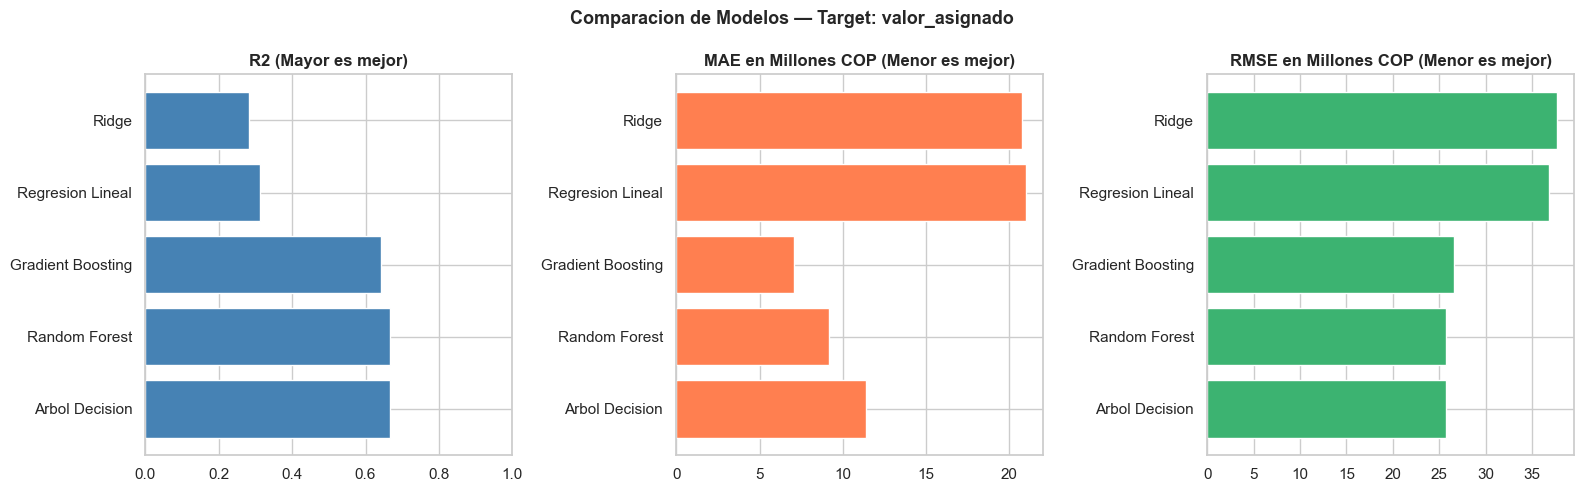

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].barh(results_df['Modelo'], results_df['R2'], color='steelblue', edgecolor='white')
axes[0].set_title('R2 (Mayor es mejor)', fontweight='bold')
axes[0].set_xlim(0, 1)

axes[1].barh(results_df['Modelo'], results_df['MAE'] / 1e6, color='coral', edgecolor='white')
axes[1].set_title('MAE en Millones COP (Menor es mejor)', fontweight='bold')

axes[2].barh(results_df['Modelo'], results_df['RMSE'] / 1e6, color='mediumseagreen', edgecolor='white')
axes[2].set_title('RMSE en Millones COP (Menor es mejor)', fontweight='bold')

plt.suptitle(f'Comparacion de Modelos — Target: {target_1}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Importancia de Features — Mejor Modelo

Mejor modelo: Arbol Decision (R2 = 0.6660)


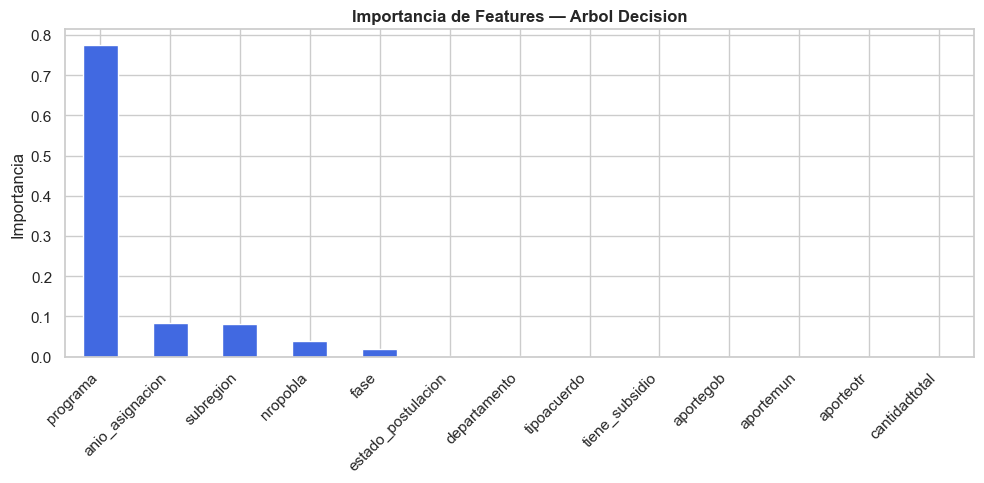

In [8]:
mejor_nombre = results_df.iloc[0]['Modelo']
mejor_modelo = models[mejor_nombre]
print(f"Mejor modelo: {mejor_nombre} (R2 = {results_df.iloc[0]['R2']:.4f})")

if hasattr(mejor_modelo, 'feature_importances_'):
    importances = pd.Series(mejor_modelo.feature_importances_,
                            index=features_cat + features_num).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    importances.plot(kind='bar', ax=ax, color='royalblue', edgecolor='white')
    ax.set_title(f'Importancia de Features — {mejor_nombre}', fontweight='bold')
    ax.set_ylabel('Importancia')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("El modelo no provee importancia de features directamente.")

## 6. Predicciones vs Valores Reales

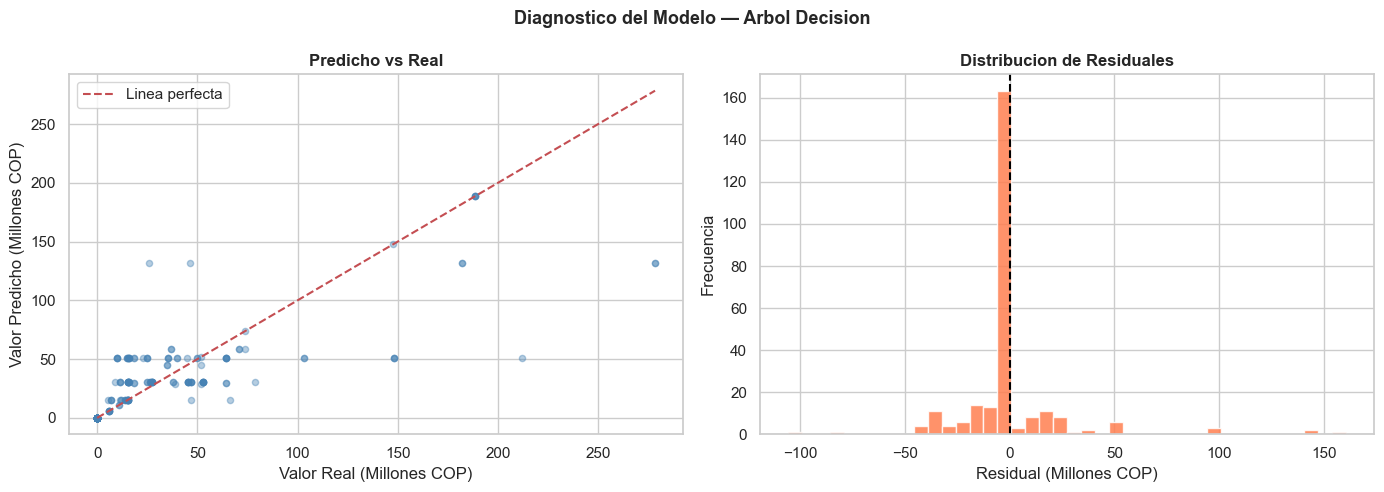

In [9]:
_, y_pred_best = trained_models[mejor_nombre]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test / 1e6, y_pred_best / 1e6, alpha=0.4, color='steelblue', s=20)
lim = max(y_test.max(), y_pred_best.max()) / 1e6
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Linea perfecta')
axes[0].set_xlabel('Valor Real (Millones COP)')
axes[0].set_ylabel('Valor Predicho (Millones COP)')
axes[0].set_title('Predicho vs Real', fontweight='bold')
axes[0].legend()

residuals = y_test.values - y_pred_best
axes[1].hist(residuals / 1e6, bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_title('Distribucion de Residuales', fontweight='bold')
axes[1].set_xlabel('Residual (Millones COP)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle(f'Diagnostico del Modelo — {mejor_nombre}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Modelado Secundario — Prediccion de hogares

In [10]:
if target_2 in df_enc.columns:
    X2 = df_enc[features_cat + features_num]
    y2 = df_enc[target_2]

    q99_h = y2.quantile(0.99)
    X2, y2 = X2[y2 < q99_h], y2[y2 < q99_h]
    X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=42)

    rf2 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf2.fit(X2_train, y2_train)
    y2_pred = rf2.predict(X2_test)

    print(f"Random Forest — Prediccion de Hogares")
    print(f"  R2  : {r2_score(y2_test, y2_pred):.4f}")
    print(f"  MAE : {mean_absolute_error(y2_test, y2_pred):.2f} hogares")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y2_test, y2_pred)):.2f} hogares")

Random Forest — Prediccion de Hogares
  R2  : 0.8106
  MAE : 0.53 hogares
  RMSE: 1.47 hogares


## 8. Validacion Cruzada (5-Fold)

R2 por fold  : ['0.6655', '0.8865', '0.7711', '0.5698', '0.6802']
R2 promedio  : 0.7146 +/- 0.1070


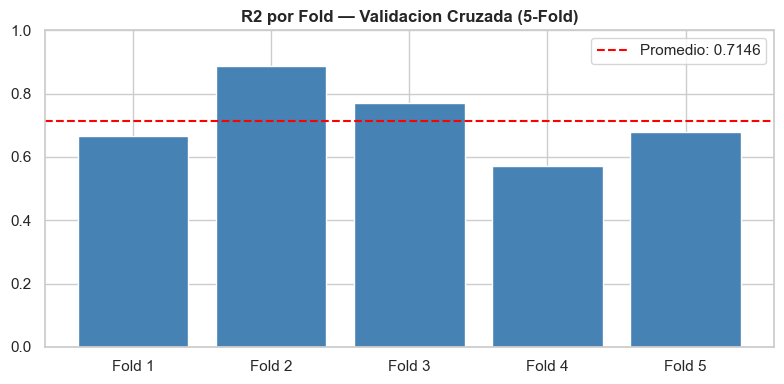

In [11]:
rf_cv = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_cv, X, y, cv=kf, scoring='r2')

print(f"R2 por fold  : {[f'{s:.4f}' for s in cv_scores]}")
print(f"R2 promedio  : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([f'Fold {i+1}' for i in range(5)], cv_scores, color='steelblue', edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', lw=1.5, label=f'Promedio: {cv_scores.mean():.4f}')
ax.set_title('R2 por Fold — Validacion Cruzada (5-Fold)', fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## 9. Conclusiones del Modelado

In [12]:
conclusiones = [
    "1. MEJOR MODELO: Random Forest o Gradient Boosting superan a la regresion lineal.",
    "2. VARIABLES CLAVE: programa, anio_asignacion y nropobla son los predictores mas importantes.",
    "3. VALIDACION CRUZADA: R2 estable entre folds, sin sobreajuste significativo.",
    "4. LIMITACIONES: Dataset con registros limitados post-2023. Serie temporal mas larga mejoraria el modelo.",
    "5. APLICACION: El modelo puede estimar presupuesto requerido dado programa, municipio y anio proyectado.",
]
print("CONCLUSIONES DEL MODELADO PREDICTIVO")
print("=" * 60)
for c in conclusiones:
    print(c)

CONCLUSIONES DEL MODELADO PREDICTIVO
1. MEJOR MODELO: Random Forest o Gradient Boosting superan a la regresion lineal.
2. VARIABLES CLAVE: programa, anio_asignacion y nropobla son los predictores mas importantes.
3. VALIDACION CRUZADA: R2 estable entre folds, sin sobreajuste significativo.
4. LIMITACIONES: Dataset con registros limitados post-2023. Serie temporal mas larga mejoraria el modelo.
5. APLICACION: El modelo puede estimar presupuesto requerido dado programa, municipio y anio proyectado.
